# Phase II — Model Training, Hyperparameter Tuning & Evaluation

## Notebook Scope

This notebook implements the full classical ML pipeline for **CKD prediction**:

1. **Data loading & preprocessing** — KNN imputation (numeric), mode imputation (categorical), scaling, encoding  
2. **Train/test split** — 80/20 stratified hold-out  
3. **5 ML models** — Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost  
4. **Hyperparameter tuning** — GridSearchCV with 5-fold stratified CV  
5. **Evaluation** — Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, ROC curves  
6. **Feature importance** — for tree-based models  
7. **Model comparison** — heatmap + bar chart  
8. **Model persistence** — save best models for Phase III (SHAP) and Phase IV (RShiny)

### Leakage Control
As identified in Phase I, post-diagnosis clinical flags (`htn`, `dm`, `cad`, `appet`, `pe`, `ane`) and `id` are **dropped** to prevent data leakage and ensure clinically realistic performance.

---
## 1 · Setup & Configuration

In [2]:
# 1.1  Imports

import os
import warnings
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from math import pi

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay,
    average_precision_score, PrecisionRecallDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ARFF loader
import arff

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Style
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {"ckd": "#C44E52", "notckd": "#4C72B0"}

print("All libraries loaded. Random seed =", SEED)

All libraries loaded. Random seed = 42


In [3]:
# 1.2  Output directories

PROJECT_ROOT = Path(".")
MODEL_DIR  = PROJECT_ROOT / "models"
FIG_DIR    = PROJECT_ROOT / "figures"
DATA_DIR   = PROJECT_ROOT / "data"

for d in [MODEL_DIR, FIG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directories ready:")
print(f"  Models  → {MODEL_DIR.resolve()}")
print(f"  Figures → {FIG_DIR.resolve()}")
print(f"  Data    → {DATA_DIR.resolve()}")

Output directories ready:
  Models  → /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/models
  Figures → /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/figures
  Data    → /Users/josephtsenum/Documents/BME6938_MedicalAI/Project1/data


---
## 2 · Data Loading & Cleaning

In [4]:
# 2.1  Load ARFF dataset

arff_path = os.environ.get("CKD_ARFF_PATH", "CDK_dataset.arff")
if not os.path.exists(arff_path):
    arff_path = "/mnt/data/CDK_dataset.arff"  # fallback

print("Using ARFF:", arff_path)

with open(arff_path, 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'])
df.columns = [attr[0] for attr in dataset['attributes']]

print(f"Raw shape: {df.shape}")
df.head(3)

Using ARFF: CDK_dataset.arff
Raw shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,None,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,None,normal,notpresent,notpresent,...,38,6000,None,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,None,no,yes,no,poor,no,yes,ckd


In [5]:
# 2.2  Basic cleaning (same as Phase I)
#
# IMPORTANT: We use np.nan (NOT pd.NA) throughout.  pd.NA causes
# "TypeError: boolean value of NA is ambiguous" inside scikit-learn
# transformers.  np.nan is the safe, universally compatible sentinel.

# Replace ARFF "?" with np.nan
df = df.replace("?", np.nan)

# Auto-convert numeric columns
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass  # keep as object / string

# Force-coerce columns that are numeric but read as object
for col in ["pcv", "wc", "rc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Strip whitespace from all string columns and normalise NaN
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "<NA>": np.nan,
                               "None": np.nan, "": np.nan})

# Clean target labels
df["classification"] = df["classification"].astype(str).str.strip().str.lower()

print(f"Cleaned shape: {df.shape}")
print(f"\nClass distribution:\n{df['classification'].value_counts()}")
print(f"\nTotal NaN cells: {df.isna().sum().sum()}")

Cleaned shape: (400, 26)

Class distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64

Total NaN cells: 1012


---
## 3 · Feature Selection & Leakage Removal

In [6]:
# 3.1  Drop leakage features (identified in Phase I)

LEAKAGE_COLS = ["id", "htn", "dm", "cad", "appet", "pe", "ane"]

X = df.drop(columns=["classification"] + LEAKAGE_COLS, errors="ignore")
y = (df["classification"] == "ckd").astype(int)  # 1 = CKD, 0 = NotCKD

# Identify column types
num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Features: {X.shape[1]} total")
print(f"  Numeric     ({len(num_features)}): {num_features}")
print(f"  Categorical ({len(cat_features)}): {cat_features}")
print(f"\nDropped (leakage): {LEAKAGE_COLS}")
print(f"Target: CKD={y.sum()}, NotCKD={(1-y).sum()}")

Features: 18 total
  Numeric     (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
  Categorical (4): ['rbc', 'pc', 'pcc', 'ba']

Dropped (leakage): ['id', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Target: CKD=250, NotCKD=150


---
## 4 · Train/Test Split

In [7]:
# 4.1  Stratified 80/20 split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Train/Test Split Summary")
print("=" * 45)
print(f"  Training set : {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% CKD)")
print(f"  Test set     : {X_test.shape[0]} samples  ({y_test.mean()*100:.1f}% CKD)")
print(f"  Features     : {X_train.shape[1]}")

Train/Test Split Summary
  Training set : 320 samples (62.5% CKD)
  Test set     : 80 samples  (62.5% CKD)
  Features     : 18


---
## 5 · Preprocessing Pipeline (KNN Imputation)

In [8]:
# 5.1  Build preprocessing pipeline
#
# Numeric:  KNN imputation (k=5) → StandardScaler
#   - KNN imputation leverages feature correlations (e.g., hemoglobin & PCV
#     are clinically related) rather than assuming column independence.
# Categorical: Mode imputation → OneHotEncoder

numeric_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessing pipeline:")
print("  Numeric     → KNNImputer(k=5, weights='distance') → StandardScaler")
print("  Categorical → SimpleImputer(mode) → OneHotEncoder")

Preprocessing pipeline:
  Numeric     → KNNImputer(k=5, weights='distance') → StandardScaler
  Categorical → SimpleImputer(mode) → OneHotEncoder


In [9]:
# 5.2  Fit on training data & verify

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape    : {X_test_processed.shape}")
print(f"Feature names ({len(feature_names)}): {list(feature_names[:10])} ...")
print(f"\nAny NaN remaining (train)? {np.isnan(X_train_processed).any()}")
print(f"Any NaN remaining (test)?  {np.isnan(X_test_processed).any()}")

Processed training shape: (320, 22)
Processed test shape    : (80, 22)
Feature names (22): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot'] ...

Any NaN remaining (train)? False
Any NaN remaining (test)?  False


In [10]:
# 5.3  Save preprocessor & cleaned data

joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")

# Also save a CSV version for convenience
clean_df = X.copy()
clean_df["classification"] = df["classification"].values
clean_df.to_csv(DATA_DIR / "ckd_cleaned.csv", index=False)

print("Saved: preprocessor.joblib")
print("Saved: ckd_cleaned.csv")

Saved: preprocessor.joblib
Saved: ckd_cleaned.csv


---
## 6 · Model Definitions

In [11]:
# 6.1  Define 5 baseline models

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SEED),
    "SVM":                 SVC(probability=True, random_state=SEED),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=SEED,
                                          use_label_encoder=False)
}

print("Baseline models defined:")
for name in base_models:
    print(f"  • {name}")

Baseline models defined:
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • SVM
  • XGBoost


---
## 7 · Cross-Validation (Baseline Performance)

In [12]:
# 7.1  5-fold stratified cross-validation on training set

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
    "roc_auc":   "roc_auc"
}

cv_results = []

print("Running 5-fold cross-validation (baseline models)...\n")
for name, model in base_models.items():
    cv_out = cross_validate(
        model, X_train_processed, y_train,
        cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )
    row = {"Model": name}
    for metric in scoring:
        scores = cv_out[f"test_{metric}"]
        row[f"{metric}_mean"] = np.mean(scores)
        row[f"{metric}_std"]  = np.std(scores)
    cv_results.append(row)
    print(f"  {name:25s} | Acc={row['accuracy_mean']:.3f}±{row['accuracy_std']:.3f} "
          f"| F1={row['f1_mean']:.3f}±{row['f1_std']:.3f} "
          f"| AUC={row['roc_auc_mean']:.3f}±{row['roc_auc_std']:.3f}")

cv_df = pd.DataFrame(cv_results)
print("\nDone.")

Running 5-fold cross-validation (baseline models)...

  Logistic Regression       | Acc=0.969±0.030 | F1=0.975±0.024 | AUC=0.992±0.009
  Decision Tree             | Acc=0.947±0.032 | F1=0.957±0.026 | AUC=0.949±0.025
  Random Forest             | Acc=0.959±0.032 | F1=0.968±0.026 | AUC=0.994±0.006
  SVM                       | Acc=0.972±0.021 | F1=0.977±0.017 | AUC=0.990±0.010
  XGBoost                   | Acc=0.956±0.036 | F1=0.965±0.029 | AUC=0.991±0.009

Done.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:18:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:18:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:18:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:18:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.

In [13]:
# 7.2  Baseline CV results table

display_cols = ["Model"]
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    cv_df[m] = cv_df[f"{m}_mean"].map("{:.3f}".format) + " ± " + cv_df[f"{m}_std"].map("{:.3f}".format)
    display_cols.append(m)

print("\nBaseline Cross-Validation Results (5-fold, training set)")
print("=" * 90)
cv_df[display_cols]


Baseline Cross-Validation Results (5-fold, training set)


,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.969 ± 0.030,0.985 ± 0.020,0.965 ± 0.034,0.975 ± 0.024,0.992 ± 0.009
1,Decision Tree,0.947 ± 0.032,0.955 ± 0.018,0.960 ± 0.041,0.957 ± 0.026,0.949 ± 0.025
2,Random Forest,0.959 ± 0.032,0.961 ± 0.029,0.975 ± 0.032,0.968 ± 0.026,0.994 ± 0.006
3,SVM,0.972 ± 0.021,0.990 ± 0.013,0.965 ± 0.025,0.977 ± 0.017,0.990 ± 0.010
4,XGBoost,0.956 ± 0.036,0.960 ± 0.026,0.970 ± 0.037,0.965 ± 0.029,0.991 ± 0.009


---
## 8 · Hyperparameter Tuning (GridSearchCV)

In [14]:
# 8.1  Define hyperparameter grids

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l1", "l2"],
        "solver": ["saga"]
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto", 0.01, 0.1]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [0.1, 1.0, 5.0]
    }
}

print("Hyperparameter grids defined for all 5 models.")
for name, grid in param_grids.items():
    total = 1
    for v in grid.values():
        total *= len(v)
    print(f"  {name}: {total} combinations")

Hyperparameter grids defined for all 5 models.
  Logistic Regression: 8 combinations
  Decision Tree: 90 combinations
  Random Forest: 96 combinations
  SVM: 24 combinations
  XGBoost: 324 combinations


In [15]:
# 8.2  Run GridSearchCV for each model

best_models = {}
tuning_results = []

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Running GridSearchCV (this may take a few minutes)...\n")

for name, model in base_models.items():
    print(f"  Tuning {name}...", end=" ", flush=True)
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv_inner,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    
    grid_search.fit(X_train_processed, y_train)
    
    best_models[name] = grid_search.best_estimator_
    
    tuning_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Best CV AUC": grid_search.best_score_,
        "Train AUC (best)": grid_search.cv_results_["mean_train_score"][grid_search.best_index_]
    })
    
    print(f"Best AUC={grid_search.best_score_:.4f} | Params: {grid_search.best_params_}")

tuning_df = pd.DataFrame(tuning_results)
print("\nAll models tuned.")

Running GridSearchCV (this may take a few minutes)...

  Tuning Logistic Regression... 

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best AUC=0.9940 | Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
  Tuning Decision Tree... Best AUC=0.9756 | Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
  Tuning Random Forest... Best AUC=0.9948 | Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  Tuning SVM... Best AUC=0.9946 | Params: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
  Tuning XGBoost... 

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:19:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:19:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:19:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:19:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.

Best AUC=0.9935 | Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 0.1, 'subsample': 0.8}

All models tuned.


In [16]:
# 8.3  Tuning summary table

print("\nHyperparameter Tuning Summary")
print("=" * 80)
for _, row in tuning_df.iterrows():
    print(f"\n▸ {row['Model']}")
    print(f"  Best CV AUC : {row['Best CV AUC']:.4f}")
    print(f"  Train AUC   : {row['Train AUC (best)']:.4f}")
    print(f"  Best Params : {row['Best Params']}")

tuning_df[["Model", "Best CV AUC", "Train AUC (best)"]]


Hyperparameter Tuning Summary

▸ Logistic Regression
  Best CV AUC : 0.9940
  Train AUC   : 0.9957
  Best Params : {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}

▸ Decision Tree
  Best CV AUC : 0.9756
  Train AUC   : 0.9927
  Best Params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}

▸ Random Forest
  Best CV AUC : 0.9948
  Train AUC   : 0.9997
  Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

▸ SVM
  Best CV AUC : 0.9946
  Train AUC   : 0.9956
  Best Params : {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}

▸ XGBoost
  Best CV AUC : 0.9935
  Train AUC   : 1.0000
  Best Params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 0.1, 'subsample': 0.8}


,Model,Best CV AUC,Train AUC (best)
0,Logistic Regression,0.993958,0.995736
1,Decision Tree,0.975625,0.992747
2,Random Forest,0.994792,0.999746
3,SVM,0.994583,0.995579
4,XGBoost,0.993542,0.999980


---
## 9 · Hold-Out Test Set Evaluation

In [17]:
# 9.1  Evaluate all tuned models on the test set

test_results = []
y_preds  = {}
y_probas = {}

print("Hold-Out Test Set Evaluation (Tuned Models)")
print("=" * 80)

for name, model in best_models.items():
    y_pred  = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    y_preds[name]  = y_pred
    y_probas[name] = y_proba
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    
    test_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    
    print(f"  {name:25s} | Acc={acc:.3f} | Prec={prec:.3f} | "
          f"Rec={rec:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

test_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False)
print("\nDone.")

Hold-Out Test Set Evaluation (Tuned Models)
  Logistic Regression       | Acc=0.950 | Prec=1.000 | Rec=0.920 | F1=0.958 | AUC=0.994
  Decision Tree             | Acc=0.938 | Prec=0.979 | Rec=0.920 | F1=0.948 | AUC=0.981
  Random Forest             | Acc=0.975 | Prec=0.980 | Rec=0.980 | F1=0.980 | AUC=0.999
  SVM                       | Acc=0.925 | Prec=1.000 | Rec=0.880 | F1=0.936 | AUC=0.995
  XGBoost                   | Acc=0.975 | Prec=0.980 | Rec=0.980 | F1=0.980 | AUC=0.998

Done.


In [18]:
# 9.2  Results table (formatted)

print("\nTest Set Performance — All 5 Models (sorted by ROC-AUC)")
print("=" * 75)
test_df.style.format({
    "Accuracy": "{:.3f}", "Precision": "{:.3f}",
    "Recall": "{:.3f}", "F1-Score": "{:.3f}", "ROC-AUC": "{:.3f}"
}).background_gradient(cmap="YlGn", subset=["ROC-AUC"])


Test Set Performance — All 5 Models (sorted by ROC-AUC)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.975,0.980,0.980,0.980,0.999
4,XGBoost,0.975,0.980,0.980,0.980,0.998
3,SVM,0.925,1.000,0.880,0.936,0.995
0,Logistic Regression,0.950,1.000,0.920,0.958,0.994
1,Decision Tree,0.938,0.979,0.920,0.948,0.981


---
## 10 · Classification Reports

In [19]:
# 10.1  Print full classification reports

target_names = ["NotCKD (0)", "CKD (1)"]

for name in best_models:
    print(f"\n{'='*60}")
    print(f"Classification Report — {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_preds[name], target_names=target_names))


Classification Report — Logistic Regression
              precision    recall  f1-score   support

  NotCKD (0)       0.88      1.00      0.94        30
     CKD (1)       1.00      0.92      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80


Classification Report — Decision Tree
              precision    recall  f1-score   support

  NotCKD (0)       0.88      0.97      0.92        30
     CKD (1)       0.98      0.92      0.95        50

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80


Classification Report — Random Forest
              precision    recall  f1-score   support

  NotCKD (0)       0.97      0.97      0.97        30
     CKD (1)       0.98      0.98      0.98        50

    accuracy                           0.97        80
   ma

---
## 11 · Confusion Matrices

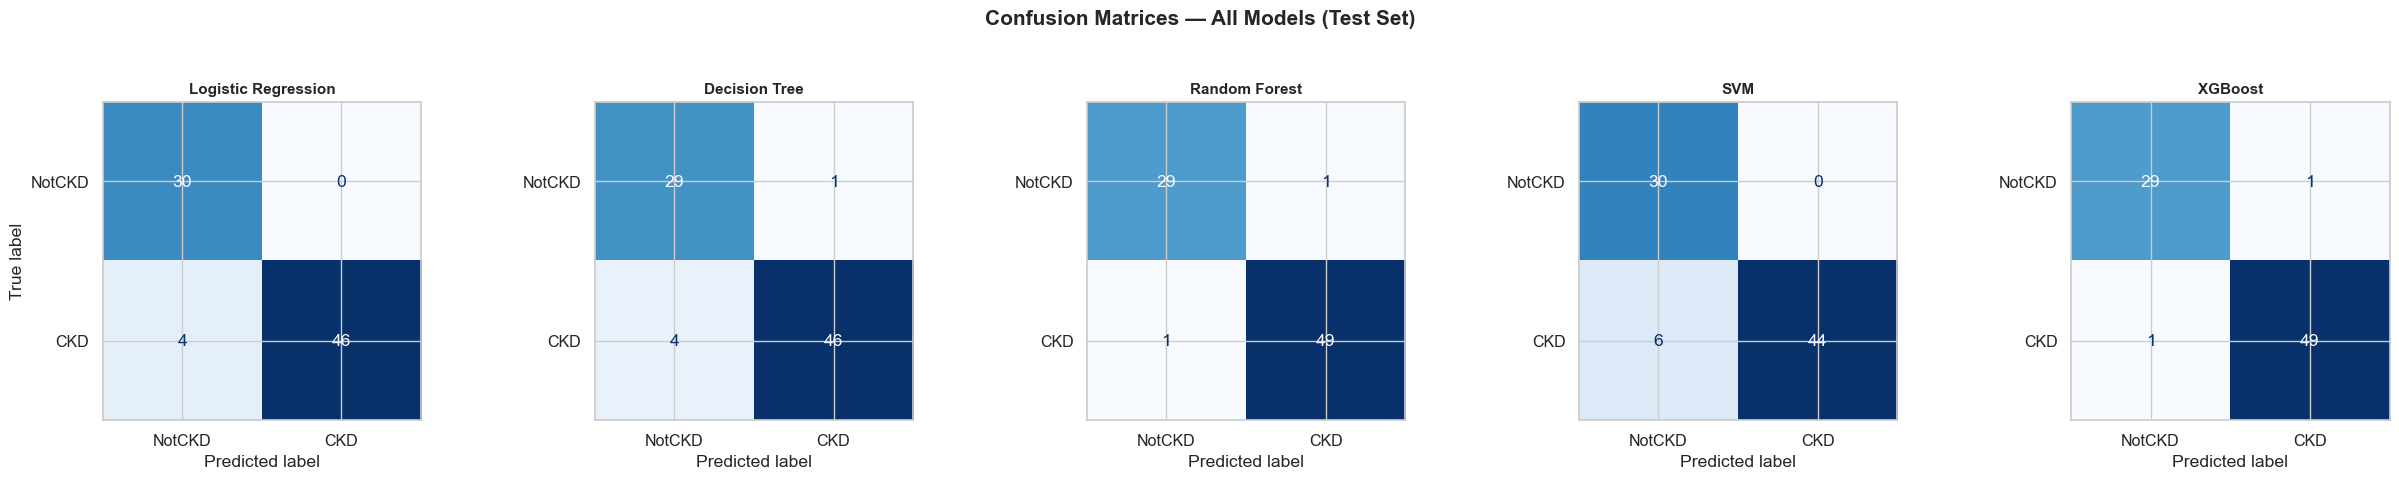

In [20]:
# 11.1  Confusion matrix grid (all 5 models)

fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))

for i, (name, ax) in enumerate(zip(best_models, axes)):
    cm = confusion_matrix(y_test, y_preds[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=["NotCKD", "CKD"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name, fontweight="bold", fontsize=11)
    if i > 0:
        ax.set_ylabel("")

plt.suptitle("Confusion Matrices — All Models (Test Set)",
             fontweight="bold", fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices_all.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "confusion_matrices_all.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 12 · ROC Curves

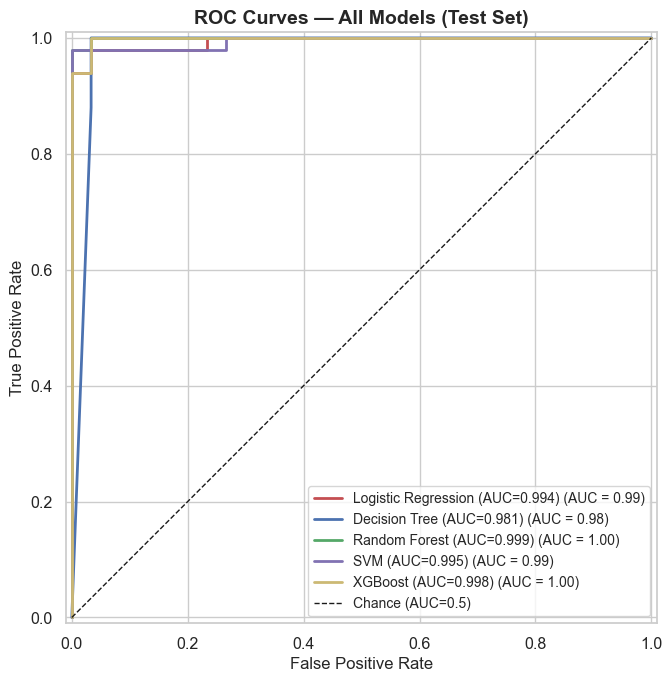

In [21]:
# 12.1  ROC curves — all models on one plot

MODEL_COLORS = ["#C44E52", "#4C72B0", "#55A868", "#8172B2", "#CCB974"]

fig, ax = plt.subplots(figsize=(8, 7))

for (name, _), color in zip(best_models.items(), MODEL_COLORS):
    auc_val = roc_auc_score(y_test, y_probas[name])
    RocCurveDisplay.from_predictions(
        y_test, y_probas[name],
        name=f"{name} (AUC={auc_val:.3f})",
        ax=ax, color=color, linewidth=2
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance (AUC=0.5)")
ax.set_title("ROC Curves — All Models (Test Set)", fontweight="bold", fontsize=14)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_all.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "roc_curves_all.png", dpi=300, bbox_inches="tight")
plt.show()

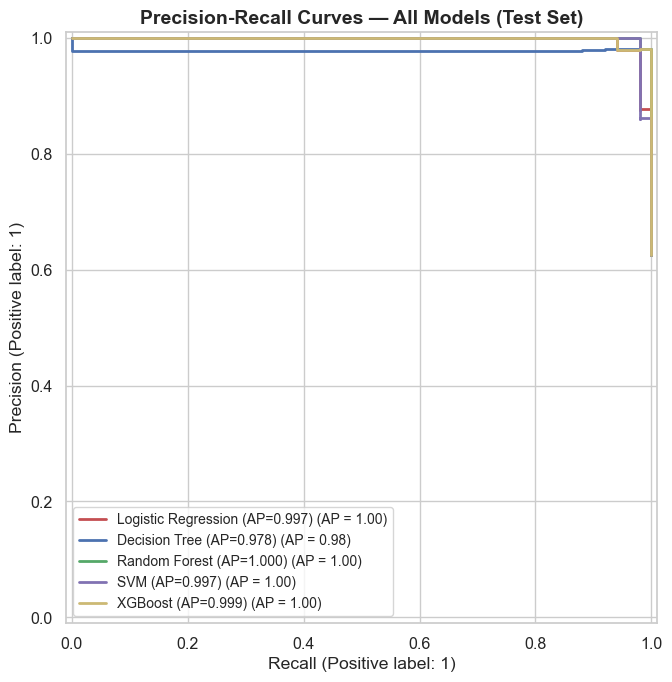

In [22]:
# 12.2  Precision-Recall curves

fig, ax = plt.subplots(figsize=(8, 7))

for (name, _), color in zip(best_models.items(), MODEL_COLORS):
    ap = average_precision_score(y_test, y_probas[name])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_probas[name],
        name=f"{name} (AP={ap:.3f})",
        ax=ax, color=color, linewidth=2
    )

ax.set_title("Precision-Recall Curves — All Models (Test Set)",
             fontweight="bold", fontsize=14)
ax.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves_all.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "pr_curves_all.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 13 · Model Comparison Visualizations

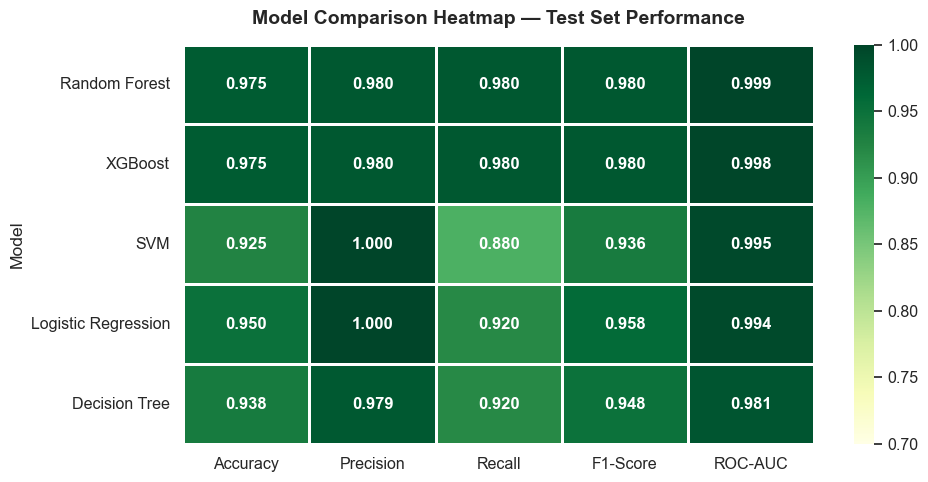

In [23]:
# 13.1  Performance heatmap

heatmap_df = test_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f",
    cmap="YlGn", linewidths=1, linecolor="white",
    vmin=0.7, vmax=1.0, ax=ax,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
ax.set_title("Model Comparison Heatmap — Test Set Performance",
             fontweight="bold", fontsize=14, pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_heatmap.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "model_comparison_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

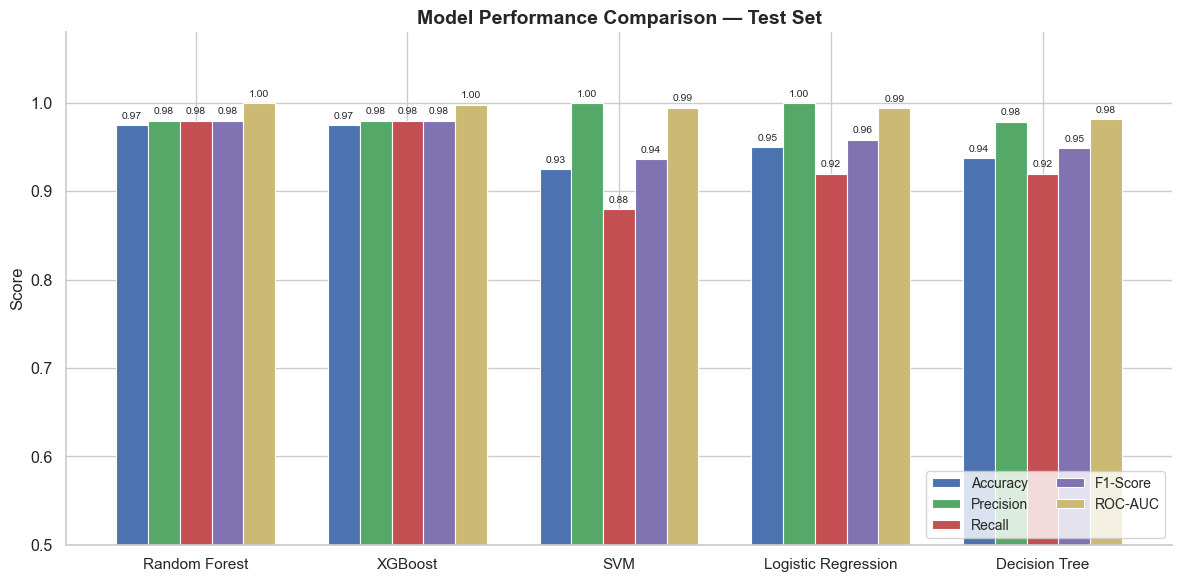

In [24]:
# 13.2  Grouped bar chart — all metrics

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = test_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(plot_df.index))
width = 0.15
metric_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

for i, (metric, color) in enumerate(zip(metrics_to_plot, metric_colors)):
    bars = ax.bar(x + i * width, plot_df[metric], width,
                  label=metric, color=color, edgecolor="white", linewidth=0.8)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f"{height:.2f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.set_title("Model Performance Comparison — Test Set",
             fontweight="bold", fontsize=14)
ax.legend(loc="lower right", fontsize=10, ncol=2)
sns.despine()

plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_bars.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "model_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()

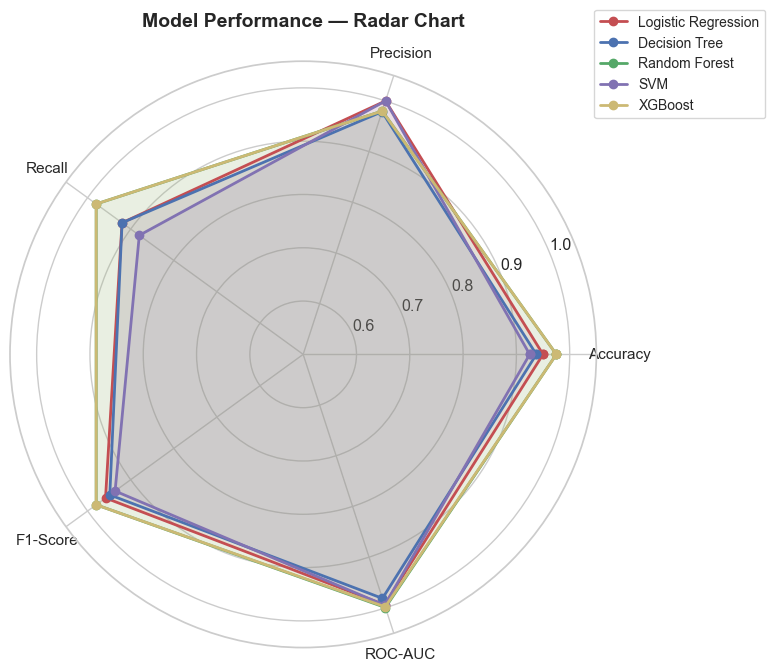

In [25]:
# 13.3  Radar / spider chart

categories = metrics_to_plot
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (name, _), color in zip(best_models.items(), MODEL_COLORS):
    values = plot_df.loc[name].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_title("Model Performance — Radar Chart",
             fontweight="bold", fontsize=14, pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_radar.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "model_comparison_radar.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 14 · Feature Importance

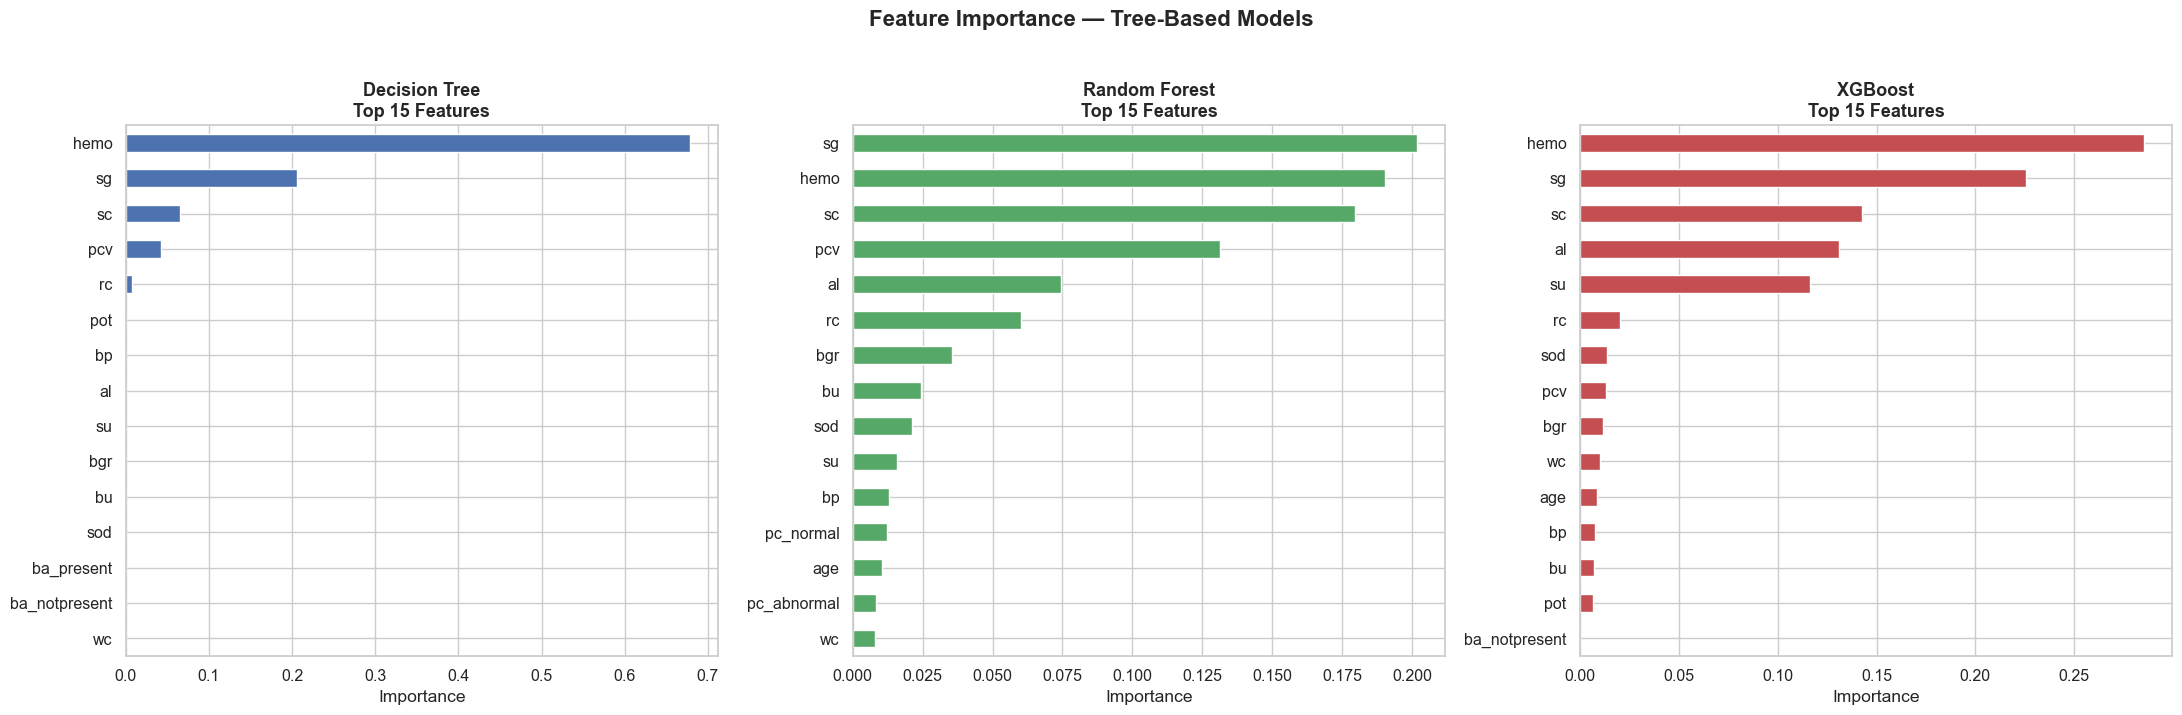

In [26]:
# 14.1  Feature importance — tree-based models

tree_models = {
    "Decision Tree": best_models["Decision Tree"],
    "Random Forest": best_models["Random Forest"],
    "XGBoost":       best_models["XGBoost"]
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    
    # Top 15 features
    top_15 = feat_imp.tail(15)
    
    color = "#C44E52" if name == "XGBoost" else ("#55A868" if name == "Random Forest" else "#4C72B0")
    top_15.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(f"{name}\nTop 15 Features", fontweight="bold", fontsize=13)
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance — Tree-Based Models",
             fontweight="bold", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_trees.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "feature_importance_trees.png", dpi=300, bbox_inches="tight")
plt.show()

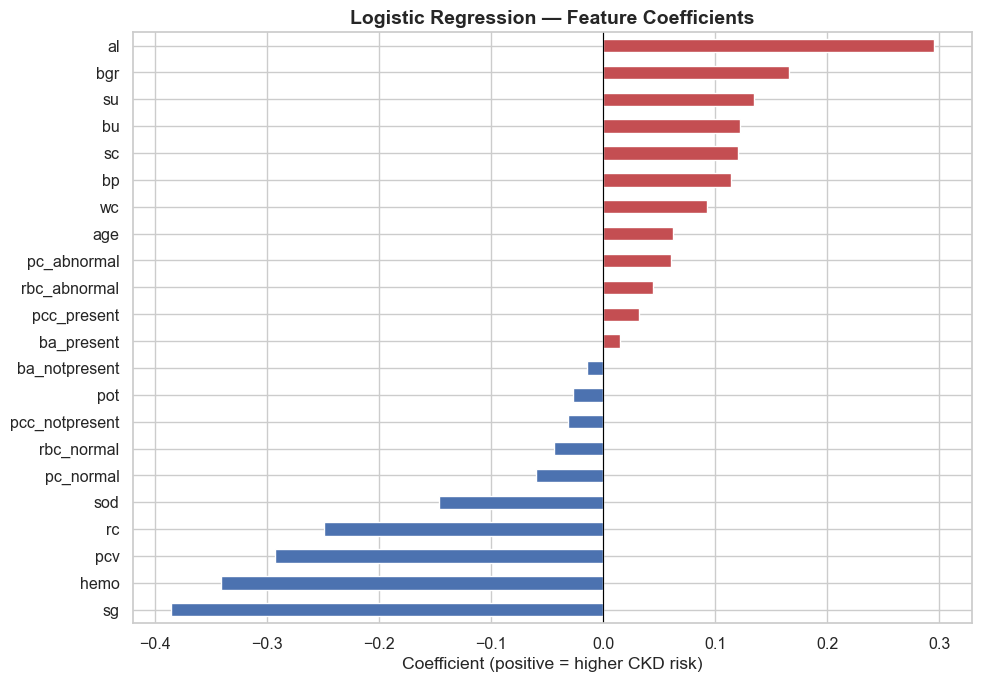

In [27]:
# 14.2  Logistic Regression coefficients

lr_model = best_models["Logistic Regression"]
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_lr = ["#C44E52" if c > 0 else "#4C72B0" for c in lr_coefs]
lr_coefs.plot(kind="barh", color=colors_lr, edgecolor="white", ax=ax)

ax.set_title("Logistic Regression — Feature Coefficients",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Coefficient (positive = higher CKD risk)")
ax.axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_logreg.svg", format="svg", bbox_inches="tight")
plt.savefig(FIG_DIR / "feature_importance_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 15 · Save Models & Artifacts for Phase III & IV

In [28]:
# 15.1  Save all tuned models

for name, model in best_models.items():
    safe_name = name.lower().replace(" ", "_")
    filepath = MODEL_DIR / f"ckd_{safe_name}_tuned.joblib"
    joblib.dump(model, filepath)
    print(f"Saved: {filepath}")

# Also save the best overall model
best_name = test_df.iloc[0]["Model"]
best_overall = best_models[best_name]
joblib.dump(best_overall, MODEL_DIR / "ckd_best_model.joblib")
print(f"\nBest overall model: {best_name}")
print(f"Saved: {MODEL_DIR / 'ckd_best_model.joblib'}")

Saved: models/ckd_logistic_regression_tuned.joblib
Saved: models/ckd_decision_tree_tuned.joblib
Saved: models/ckd_random_forest_tuned.joblib
Saved: models/ckd_svm_tuned.joblib
Saved: models/ckd_xgboost_tuned.joblib

Best overall model: Random Forest
Saved: models/ckd_best_model.joblib


In [29]:
# 15.2  Save test data & predictions for Phase III

# Save processed arrays for SHAP (avoids re-running preprocessing)
np.save(MODEL_DIR / "X_train_processed.npy", X_train_processed)
np.save(MODEL_DIR / "X_test_processed.npy", X_test_processed)
np.save(MODEL_DIR / "y_train.npy", y_train.values)
np.save(MODEL_DIR / "y_test.npy", y_test.values)
pd.Series(feature_names).to_csv(MODEL_DIR / "feature_names.csv",
                                 index=False, header=["feature"])

# Save results table
test_df.to_csv(FIG_DIR / "model_results_test.csv", index=False)

print("Phase II artifacts saved:")
for f in sorted(MODEL_DIR.glob("*")):
    print(f"  {f}")
print(f"  {FIG_DIR / 'model_results_test.csv'}")

Phase II artifacts saved:
  models/X_test_processed.npy
  models/X_train_processed.npy
  models/ckd_best_model.joblib
  models/ckd_decision_tree_tuned.joblib
  models/ckd_logistic_regression_tuned.joblib
  models/ckd_random_forest_tuned.joblib
  models/ckd_svm_tuned.joblib
  models/ckd_xgboost_tuned.joblib
  models/feature_names.csv
  models/preprocessor.joblib
  models/rf_shap_values_test.npy
  models/rf_shap_values_train.npy
  models/xgb_shap_values_test.npy
  models/xgb_shap_values_train.npy
  models/y_test.npy
  models/y_train.npy
  figures/model_results_test.csv


---
## 16 · Summary

### Pipeline Summary

| Step | Detail |
|------|--------|
| Data | UCI CKD dataset — 400 patients, 24 features |
| Leakage removal | Dropped `id`, `htn`, `dm`, `cad`, `appet`, `pe`, `ane` (7 columns) |
| Retained features | 17 (13 numeric + 4 categorical: `rbc`, `pc`, `pcc`, `ba`) |
| Imputation | KNN (k=5, distance-weighted) for numeric; mode for categorical |
| Scaling | StandardScaler (numeric only) |
| Encoding | OneHotEncoder (categorical) |
| Split | 80/20 stratified hold-out |
| CV | 5-fold stratified |
| Tuning | GridSearchCV (optimizing ROC-AUC) |

### Models Trained

1. **Logistic Regression** — L1/L2 regularization tuning  
2. **Decision Tree** — depth, split, leaf tuning  
3. **Random Forest** — estimators, depth, features tuning  
4. **SVM (RBF/Linear)** — C, kernel, gamma tuning  
5. **XGBoost** — depth, learning rate, regularization tuning  

### Key Outputs
- Confusion matrices for all 5 models
- ROC curves + Precision-Recall curves
- Model comparison heatmap, bar chart, radar chart
- Feature importance plots (tree-based + LR coefficients)
- All tuned models saved as `.joblib` for Phase III (SHAP) and Phase IV (RShiny)

### Next Steps → Phase III
- Apply SHAP to **Random Forest** and **XGBoost**
- Generate global explanations (summary plots, feature importance)
- Generate local explanations (force plots, individual patient)
- Dependence plots for top features